# IRIS: Introspective Reliability-Gated Instance Selection
## Human-in-the-Loop Deep Active Learning under Imperfect Annotators

**Self-contained project notebook** — code, experiments, and results in one file.

### The idea in three bullets
- **Introspection head**: a 2-layer MLP on the backbone's *detached* penultimate
  features, trained jointly (class-balanced BCE) to predict *the probability that the
  main classifier is wrong* on an input — a learned, bounded, calibrated acquisition
  signal replacing hand-crafted softmax entropy.
- **Diversity gate**: the top β·K introspection-ranked pool samples are filtered to K by
  greedy k-center selection in feature space (seeded with the already-labeled set), so
  each human-annotation batch is informative *and* non-redundant.
- **Reliability-weighted training**: per-sample EMA losses drive small-loss weighting
  (co-teaching principle), so labels bought from a *noisy* human annotator (γ = 0.2)
  don't poison the model.

### Experimental protocol
Pool-based batch AL on **Fashion-MNIST** (500 + 5×500 labels, small CNN) and
**CIFAR-10** (1000 + 5×1000 labels, ResNet-18) against **random / entropy / BALD /
core-set** baselines, under a **clean** and a **noisy (γ=0.2)** simulated annotator,
3 seeds each; metrics: accuracy-vs-budget curves, final accuracy, AUBC, plus an
error-prediction AUROC audit of the introspection head.

### Project layout
```
IRIS/
├── src/                 # hitl_experiments.py, make_plots.py, make_numbers.py, finalize.sh
├── results/             # results.csv, summary tables, figures  (shipped: no training needed)
├── notebooks/IRIS.ipynb # this notebook
├── docs/                # literature review + per-source metadata
├── logs/                # experiments.log (the nohup run), finalize.log
├── data/                # datasets (git-ignored; downloaded on first run)
└── papers/              # reference PDFs (git-ignored: not redistributable)
```


## 1. Experiment implementation
The complete implementation (identical to `src/hitl_experiments.py`). Running this cell only *defines* everything — no training starts.

In [1]:
"""
IRIS: Introspective Reliability-gated Instance Selection for
Human-in-the-Loop Deep Active Learning.

Runs the full experimental grid:
  datasets : Fashion-MNIST, CIFAR-10, BloodMNIST (MedMNIST v2)
  methods  : random, entropy, bald, coreset, iris
             (+ diversity/reliability ablations on the two 28x28 datasets)
  oracle   : clean (noise=0.0) and noisy human annotator (noise=0.2)
  seeds    : 0, 1, 2

Results are appended incrementally to results/results.csv so partial
progress is never lost.  Designed to run unattended under nohup.
"""

import argparse
import json
import os
import random
import subprocess
import sys
import time
import traceback

import numpy as np
import torch
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import resnet18

try:
    ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:  # running inside a notebook: cwd is the project root
    ROOT = os.getcwd()
DATA_DIR = os.path.join(ROOT, "data")
RESULTS_DIR = os.path.join(ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_CSV = os.path.join(RESULTS_DIR, "results.csv")
DIAG_CSV = os.path.join(RESULTS_DIR, "diagnostics.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = os.path.join(ROOT, "checkpoints")

# Deterministic cuDNN: without this, convolution autotuning picks different
# algorithms between runs and the accuracies drift in the third decimal, which
# makes the published numbers impossible to reproduce exactly.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
BLOOD_NPZ = os.path.join(DATA_DIR, "bloodmnist.npz")

# per-dataset input shape / label space / backbone choice
DATASET_SPECS = {
    "fmnist":     dict(num_classes=10, in_ch=1, backbone="smallcnn"),
    "cifar10":    dict(num_classes=10, in_ch=3, backbone="resnet18"),
    "bloodmnist": dict(num_classes=8,  in_ch=3, backbone="smallcnn"),
}


# --------------------------------------------------------------------------
# Reproducibility
# --------------------------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def _worker_init(worker_id):
    """Give each DataLoader worker a deterministic, distinct seed."""
    s = torch.initial_seed() % 2**32
    np.random.seed(s + worker_id)
    random.seed(s + worker_id)


# --------------------------------------------------------------------------
# Data
# --------------------------------------------------------------------------
def get_datasets(name):
    if name == "fmnist":
        tf_train = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        train_aug = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf_train)
        train_plain = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=tf_test)
        test = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=tf_test)
    elif name == "cifar10":
        mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
        tf_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        train_aug = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=tf_train)
        train_plain = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=tf_test)
        test = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=tf_test)
    elif name == "bloodmnist":
        # MedMNIST v2 blood-cell microscopy: 8 leukocyte classes, 28x28 RGB,
        # 11,959 train / 3,421 test. Stands in for the expert-annotation
        # regime the paper targets: a competent base model, a specialist
        # oracle, and a modest label budget.
        mean, std = (0.8162, 0.6685, 0.6955), (0.2152, 0.2415, 0.1175)
        tf_train = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        tf_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
        train_aug = NpzImageDataset(BLOOD_NPZ, "train", tf_train)
        train_plain = NpzImageDataset(BLOOD_NPZ, "train", tf_test)
        test = NpzImageDataset(BLOOD_NPZ, "test", tf_test)
    else:
        raise ValueError(name)
    return train_aug, train_plain, test


class NpzImageDataset(Dataset):
    """A MedMNIST-style .npz split (images NHWC uint8, labels Nx1) exposed
    with the same interface as the torchvision datasets above."""

    def __init__(self, path, split, transform):
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"{path} missing - fetch it with:\n  curl -L -o {path} "
                "https://zenodo.org/records/10519652/files/bloodmnist.npz")
        d = np.load(path)
        self.images = d[f"{split}_images"]
        self.targets = [int(t) for t in d[f"{split}_labels"].ravel()]
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        return self.transform(Image.fromarray(self.images[i])), self.targets[i]


class LabeledSubset(Dataset):
    """Subset of a base dataset with (possibly noisy) oracle labels and stable
    per-sample ids so the trainer can track per-sample EMA losses."""

    def __init__(self, base, indices, labels):
        self.base = base
        self.indices = list(indices)
        self.labels = list(labels)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, _ = self.base[self.indices[i]]
        return x, self.labels[i], i


# --------------------------------------------------------------------------
# Models: backbone returns (logits, penultimate_features);
# IntrospectionHead is the auxiliary error-prediction branch.
# --------------------------------------------------------------------------
class SmallCNN(nn.Module):
    """Compact CNN for the 28x28 datasets (Fashion-MNIST, BloodMNIST).
    Penultimate feature dim = 256."""

    feat_dim = 256

    def __init__(self, num_classes=10, in_ch=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc1 = nn.Linear(64 * 7 * 7, self.feat_dim)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(self.feat_dim, num_classes)

    def forward(self, x):
        h = self.features(x).flatten(1)
        feat = F.relu(self.fc1(h))
        logits = self.fc2(self.dropout(feat))
        return logits, feat


class ResNet18C(nn.Module):
    """ResNet-18 adapted to 32x32 inputs. Penultimate feature dim = 512."""

    feat_dim = 512

    def __init__(self, num_classes=10):
        super().__init__()
        net = resnet18(num_classes=num_classes)
        net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        net.maxpool = nn.Identity()
        self.stem = nn.Sequential(
            net.conv1, net.bn1, net.relu, net.maxpool,
            net.layer1, net.layer2, net.layer3, net.layer4, net.avgpool,
        )
        self.dropout = nn.Dropout(0.25)
        self.fc = net.fc

    def forward(self, x):
        feat = self.stem(x).flatten(1)
        logits = self.fc(self.dropout(feat))
        return logits, feat


class IntrospectionHead(nn.Module):
    """Auxiliary branch predicting P(main classifier is wrong) from
    (detached) penultimate features."""

    def __init__(self, feat_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, feat):
        return self.net(feat).squeeze(-1)


class LossPredictionModule(nn.Module):
    """Yoo & Kweon (2019), Learning Loss for Active Learning.

    Predicts the target network's loss from its penultimate feature.  Two
    deliberate differences from our introspection head, because they are the
    differences the paper claims: the target is the raw, unbounded loss rather
    than a bounded error probability, and the features are NOT detached, so
    this module's gradient does reach the backbone.
    """

    def __init__(self, feat_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(feat_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 1))

    def forward(self, feat):
        return self.net(feat).squeeze(-1)


def loss_pred_ranking_loss(pred, target, margin=1.0):
    """Pairwise ranking objective from Learning-Loss.

    The batch is split in half and paired up; the module is asked only to get
    the *ordering* of each pair right.  This is what makes the method robust
    to the loss changing scale as training proceeds.
    """
    m = pred.numel() - (pred.numel() % 2)
    if m < 2:
        return pred.sum() * 0.0
    half = m // 2
    pi, pj = pred[:m][:half], pred[:m][half:]
    ti, tj = target[:m][:half].detach(), target[:m][half:].detach()
    sign = torch.where(ti > tj, 1.0, -1.0)
    return torch.clamp(margin - sign * (pi - pj), min=0).mean()


def make_lpm(dataset, seed):
    torch.manual_seed(seed + 7919)
    spec = DATASET_SPECS[dataset]
    dim = 256 if spec["backbone"] == "smallcnn" else 512
    return LossPredictionModule(dim).to(DEVICE)


def badge_kmeanspp(probs, feats, k, rng):
    """BADGE (Ash et al., 2020): k-means++ seeding on gradient embeddings.

    The embedding is g_i = (p_i - e_{yhat_i}) outer f_i, the gradient of the
    cross-entropy w.r.t. the last linear layer.  Materialising it costs C*d
    floats per point, which is 5,120 for the ResNet.  We never build it:
    because <a_i (x) f_i, a_j (x) f_j> = (a_i.a_j)(f_i.f_j), squared distances
    follow exactly from the two small inner products, so this is the real
    BADGE embedding rather than an approximation of it.
    """
    a = probs.clone()
    a[torch.arange(a.shape[0]), probs.argmax(1)] -= 1.0      # p - e_yhat
    a = a.to(DEVICE).float()
    f = feats.to(DEVICE).float()
    sq = (a * a).sum(1) * (f * f).sum(1)                     # ||g_i||^2

    def sqdist_to(c):
        return (sq + sq[c] - 2.0 * (a @ a[c]) * (f @ f[c])).clamp_min_(0)

    first = int(rng.integers(len(sq)))
    chosen = [first]
    mind = sqdist_to(first)
    for _ in range(1, min(k, len(sq))):
        total = float(mind.sum())
        if total <= 0:                                        # degenerate pool
            remaining = [i for i in range(len(sq)) if i not in set(chosen)]
            chosen.append(int(rng.choice(remaining)))
        else:
            probs_cpu = (mind / mind.sum()).cpu().numpy().astype("float64")
            probs_cpu /= probs_cpu.sum()
            chosen.append(int(rng.choice(len(sq), p=probs_cpu)))
        mind = torch.minimum(mind, sqdist_to(chosen[-1]))
    return chosen


def kcenter_greedy_grad(a_pool, f_pool, k, a_init=None, f_init=None):
    """Greedy k-center on BADGE gradient embeddings g = a (x) f.

    Same covering objective as our feature-space gate, but in the geometry
    BADGE uses, where distance reflects disagreement in the *gradient* the
    sample would induce rather than in raw representation.  Distances come
    from the outer-product identity, so the C*d embedding is never built.
    """
    a_pool = a_pool.to(DEVICE).float()
    f_pool = f_pool.to(DEVICE).float()
    sq = (a_pool * a_pool).sum(1) * (f_pool * f_pool).sum(1)
    n = sq.numel()
    mind = torch.full((n,), float("inf"), device=DEVICE)
    if a_init is not None and len(a_init):
        ai = a_init.to(DEVICE).float()
        fi = f_init.to(DEVICE).float()
        sqi = (ai * ai).sum(1) * (fi * fi).sum(1)
        for s0 in range(0, ai.shape[0], 512):          # chunked: bounds memory
            A, F_, S = ai[s0:s0 + 512], fi[s0:s0 + 512], sqi[s0:s0 + 512]
            d = (sq[:, None] + S[None, :]
                 - 2.0 * (a_pool @ A.T) * (f_pool @ F_.T))
            mind = torch.minimum(mind, d.clamp_min_(0).min(1).values)
    chosen = []
    for _ in range(min(k, n)):
        c = int(torch.argmax(mind))
        chosen.append(c)
        d = (sq + sq[c]
             - 2.0 * (a_pool @ a_pool[c]) * (f_pool @ f_pool[c])).clamp_min_(0)
        mind = torch.minimum(mind, d)
        mind[c] = -1.0
    return chosen


def _grad_embed_parts(backbone, ds, indices):
    """The (a, f) factors of the BADGE gradient embedding for given indices."""
    probs, feats = predict(backbone, ds, indices)
    a = probs.clone()
    a[torch.arange(a.shape[0]), probs.argmax(1)] -= 1.0
    return a, feats


@torch.no_grad()
def loss_predictions(backbone, lpm, ds, indices, batch_size=256):
    backbone.eval()
    lpm.eval()
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    out = []
    for x, _ in loader:
        _, feat = backbone(x.to(DEVICE))
        out.append(lpm(feat).cpu())
    return torch.cat(out)


def make_model(dataset, seed):
    torch.manual_seed(seed)
    spec = DATASET_SPECS[dataset]
    if spec["backbone"] == "smallcnn":
        backbone = SmallCNN(num_classes=spec["num_classes"], in_ch=spec["in_ch"])
    else:
        backbone = ResNet18C(num_classes=spec["num_classes"])
    head = IntrospectionHead(backbone.feat_dim)
    return backbone.to(DEVICE), head.to(DEVICE)


# --------------------------------------------------------------------------
# Training with joint introspection head and optional reliability weighting
# --------------------------------------------------------------------------
def train_model(backbone, head, labeled_ds, cfg, use_reliability, noise_rate,
                lpm=None, lpm_weight=1.0):
    epochs = cfg["epochs"]
    # a tiny trailing batch (e.g. 5000 % 128 = 8) destabilizes BatchNorm badly
    # enough to dent a whole round — drop it when degenerate
    drop_last = (len(labeled_ds) % cfg["batch_size"]) < 16
    gen = torch.Generator()
    gen.manual_seed(torch.initial_seed() % 2**32)
    loader = DataLoader(labeled_ds, batch_size=cfg["batch_size"], shuffle=True,
                        num_workers=2, drop_last=drop_last,
                        generator=gen, worker_init_fn=_worker_init)
    params = list(backbone.parameters()) + list(head.parameters())
    if lpm is not None:
        params += list(lpm.parameters())
    opt = torch.optim.SGD(params, lr=cfg["lr"], momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    n = len(labeled_ds)
    ema_loss = torch.zeros(n, device=DEVICE)
    ema_init = torch.zeros(n, dtype=torch.bool, device=DEVICE)
    warmup = max(3, epochs // 5)
    err_rate = 0.5  # running estimate of P(error) for pos_weight balancing

    backbone.train()
    head.train()
    if lpm is not None:
        lpm.train()
    for ep in range(epochs):
        for x, y, idx in loader:
            x, y, idx = x.to(DEVICE), y.to(DEVICE), idx.to(DEVICE)
            logits, feat = backbone(x)
            per_sample = F.cross_entropy(logits, y, reduction="none")

            with torch.no_grad():
                cur = per_sample.detach()
                old = ema_loss[idx]
                ema_loss[idx] = torch.where(ema_init[idx], 0.7 * old + 0.3 * cur, cur)
                ema_init[idx] = True

            if use_reliability and ep >= warmup:
                # small-loss trick: keep the (1 - noise_rate) fraction with the
                # smallest EMA loss at full weight, down-weight the rest.
                k = max(1, int((1.0 - noise_rate) * per_sample.numel()))
                thresh = torch.kthvalue(ema_loss[idx], k).values
                w = torch.where(ema_loss[idx] <= thresh,
                                torch.ones_like(per_sample),
                                torch.full_like(per_sample, 0.1))
                cls_loss = (w * per_sample).sum() / w.sum()
            else:
                cls_loss = per_sample.mean()

            # introspection head: predict whether the main head is wrong,
            # on detached features so the auxiliary loss never disturbs the backbone
            with torch.no_grad():
                wrong = (logits.argmax(1) != y).float()
                err_rate = 0.95 * err_rate + 0.05 * wrong.mean().item()
            pos_weight = torch.tensor(
                min(20.0, max(1.0, (1 - err_rate) / max(err_rate, 1e-3))),
                device=DEVICE)
            aux_logit = head(feat.detach())
            aux_loss = F.binary_cross_entropy_with_logits(aux_logit, wrong,
                                                          pos_weight=pos_weight)

            total_loss = cls_loss + aux_loss
            if lpm is not None:
                # NOT detached: Learning-Loss lets this gradient reach the
                # backbone, which is the behaviour we are comparing against.
                total_loss = total_loss + lpm_weight * loss_pred_ranking_loss(
                    lpm(feat), per_sample)

            opt.zero_grad()
            total_loss.backward()
            opt.step()
        sched.step()
    return backbone, head


# --------------------------------------------------------------------------
# Inference utilities
# --------------------------------------------------------------------------
@torch.no_grad()
def predict(backbone, ds, indices=None, batch_size=256):
    """Returns (probs, feats) in eval mode for the given indices of ds."""
    backbone.eval()
    if indices is None:
        indices = range(len(ds))
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    probs, feats = [], []
    for x, _ in loader:
        logits, feat = backbone(x.to(DEVICE))
        probs.append(F.softmax(logits, 1).cpu())
        feats.append(feat.cpu())
    return torch.cat(probs), torch.cat(feats)


@torch.no_grad()
def mc_dropout_probs(backbone, ds, indices, passes=10, batch_size=256):
    """MC-dropout predictive samples: dropout active, batchnorm frozen."""
    backbone.eval()
    for m in backbone.modules():
        if isinstance(m, nn.Dropout):
            m.train()
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    all_probs = []
    for _ in range(passes):
        chunk = []
        for x, _ in loader:
            logits, _ = backbone(x.to(DEVICE))
            chunk.append(F.softmax(logits, 1).cpu())
        all_probs.append(torch.cat(chunk))
    backbone.eval()
    return torch.stack(all_probs)  # [passes, N, C]


@torch.no_grad()
def introspection_scores(backbone, head, ds, indices, batch_size=256):
    backbone.eval()
    head.eval()
    loader = DataLoader(torch.utils.data.Subset(ds, list(indices)),
                        batch_size=batch_size, num_workers=2)
    scores, feats = [], []
    for x, _ in loader:
        _, feat = backbone(x.to(DEVICE))
        scores.append(torch.sigmoid(head(feat)).cpu())
        feats.append(feat.cpu())
    return torch.cat(scores), torch.cat(feats)


@torch.no_grad()
def evaluate(backbone, test_ds, batch_size=256):
    backbone.eval()
    loader = DataLoader(test_ds, batch_size=batch_size, num_workers=2)
    correct = total = 0
    for x, y in loader:
        logits, _ = backbone(x.to(DEVICE))
        correct += (logits.argmax(1).cpu() == y).sum().item()
        total += y.numel()
    return correct / total


def kcenter_greedy(cand_feats, k, init_feats=None):
    """Greedy k-center over candidate features (optionally seeded with the
    already-labeled set's features). Returns positions into cand_feats."""
    cand = cand_feats.to(DEVICE)
    if init_feats is not None and len(init_feats) > 0:
        centers = init_feats.to(DEVICE)
        # chunk the candidate x center distance matrix to bound peak memory
        min_d = torch.full((cand.shape[0],), float("inf"), device=DEVICE)
        for s in range(0, centers.shape[0], 1024):
            d = torch.cdist(cand, centers[s:s + 1024]).min(1).values
            min_d = torch.minimum(min_d, d)
    else:
        first = 0
        min_d = torch.cdist(cand, cand[first:first + 1]).squeeze(1)
        picked = [first]
        while len(picked) < k:
            nxt = int(min_d.argmax())
            picked.append(nxt)
            d = torch.cdist(cand, cand[nxt:nxt + 1]).squeeze(1)
            min_d = torch.minimum(min_d, d)
        return picked
    picked = []
    while len(picked) < k:
        nxt = int(min_d.argmax())
        picked.append(nxt)
        d = torch.cdist(cand, cand[nxt:nxt + 1]).squeeze(1)
        min_d = torch.minimum(min_d, d)
    return picked


# --------------------------------------------------------------------------
# Acquisition functions: return positions into `pool` (a list of dataset idx)
# --------------------------------------------------------------------------
def acquire(method, k, backbone, head, plain_ds, pool, labeled_idx, rng,
            lpm=None):
    if method == "random":
        return list(rng.choice(len(pool), size=k, replace=False))

    if method == "entropy":
        probs, _ = predict(backbone, plain_ds, pool)
        ent = -(probs * probs.clamp_min(1e-12).log()).sum(1)
        return ent.topk(k).indices.tolist()

    if method == "bald":
        mc = mc_dropout_probs(backbone, plain_ds, pool, passes=10)
        mean_p = mc.mean(0)
        h_mean = -(mean_p * mean_p.clamp_min(1e-12).log()).sum(1)
        mean_h = -(mc * mc.clamp_min(1e-12).log()).sum(2).mean(0)
        mi = h_mean - mean_h
        return mi.topk(k).indices.tolist()

    if method == "learnloss":
        scores = loss_predictions(backbone, lpm, plain_ds, pool)
        return scores.topk(k).indices.tolist()

    if method in ("badge", "badge-rel"):
        probs, pool_f = predict(backbone, plain_ds, pool)
        return badge_kmeanspp(probs, pool_f, k, rng)

    if method == "coreset":
        _, pool_f = predict(backbone, plain_ds, pool)
        _, lab_f = predict(backbone, plain_ds, labeled_idx)
        return kcenter_greedy(pool_f, k, init_feats=lab_f)

    if method in ("iris", "iris-nodiv", "iris-norel", "iris-grad"):
        scores, pool_f = introspection_scores(backbone, head, plain_ds, pool)
        if method == "iris-nodiv":
            return scores.topk(k).indices.tolist()
        beta = 5
        cand_pos = scores.topk(min(beta * k, len(pool))).indices
        if method == "iris-grad":
            # same shortlist, but spread it in gradient space instead of
            # feature space -- the one thing BADGE does that we did not.
            a_c, f_c = _grad_embed_parts(
                backbone, plain_ds, [pool[int(i)] for i in cand_pos])
            a_l, f_l = _grad_embed_parts(backbone, plain_ds, labeled_idx)
            picked = kcenter_greedy_grad(a_c, f_c, k, a_l, f_l)
            return [int(cand_pos[q]) for q in picked]
        _, lab_f = predict(backbone, plain_ds, labeled_idx)
        picked_in_cand = kcenter_greedy(pool_f[cand_pos], k, init_feats=lab_f)
        return [int(cand_pos[p]) for p in picked_in_cand]

    raise ValueError(method)


# --------------------------------------------------------------------------
# Noisy human oracle
# --------------------------------------------------------------------------
def oracle_labels(true_labels, noise_rate, num_classes, rng):
    labels = list(true_labels)
    if noise_rate > 0:
        for i in range(len(labels)):
            if rng.random() < noise_rate:
                wrong = [c for c in range(num_classes) if c != labels[i]]
                labels[i] = int(rng.choice(wrong))
    return labels


# --------------------------------------------------------------------------
# Diagnostics: does the introspection head actually predict errors?
# --------------------------------------------------------------------------
@torch.no_grad()
def error_prediction_auroc(backbone, head, test_ds):
    from sklearn.metrics import roc_auc_score
    backbone.eval(); head.eval()
    loader = DataLoader(test_ds, batch_size=256, num_workers=2)
    intro, ent, err = [], [], []
    for x, y in loader:
        logits, feat = backbone(x.to(DEVICE))
        p = F.softmax(logits, 1)
        intro.append(torch.sigmoid(head(feat)).cpu())
        ent.append(-(p * p.clamp_min(1e-12).log()).sum(1).cpu())
        err.append((logits.argmax(1).cpu() != y).float())
    intro, ent, err = torch.cat(intro), torch.cat(ent), torch.cat(err)
    if err.sum() == 0 or err.sum() == len(err):
        return float("nan"), float("nan")
    return (roc_auc_score(err.numpy(), intro.numpy()),
            roc_auc_score(err.numpy(), ent.numpy()))


# --------------------------------------------------------------------------
# One full active-learning run
# --------------------------------------------------------------------------
def train_accuracy(backbone, labeled_ds):
    """Accuracy on the model's OWN labelled set.

    Used only to detect optimisation failure.  It deliberately never touches
    the test split: a model that cannot fit the data it was just trained on
    has diverged, and that is knowable from training data alone.
    """
    backbone.eval()
    loader = DataLoader(labeled_ds, batch_size=256, num_workers=2)
    ok = tot = 0
    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(DEVICE)
            y = torch.as_tensor(y).to(DEVICE)
            logits, _ = backbone(x)
            ok += (logits.argmax(1) == y).sum().item()
            tot += y.numel()
    return ok / max(tot, 1)


MAX_DIVERGENCE_RETRIES = 2


def append_csv(path, header, row):
    new = not os.path.exists(path)
    with open(path, "a") as f:
        if new:
            f.write(",".join(header) + "\n")
        f.write(",".join(str(v) for v in row) + "\n")
        f.flush()
        os.fsync(f.fileno())


def save_checkpoint(ckpt_dir, dataset, method, noise, seed, rnd, cfg,
                    backbone, head, labeled_idx, oracle_map, acc):
    """Persist one round's trained model plus everything needed to verify it.

    The state dicts alone are not evidence: the accuracy a checkpoint claims is
    only checkable if you also know which examples it was trained on and which
    labels the (possibly lying) oracle returned for them.  Both go in the file.
    """
    os.makedirs(ckpt_dir, exist_ok=True)
    name = f"{dataset}_{method}_noise{noise}_seed{seed}_round{rnd}.pt"
    path = os.path.join(ckpt_dir, name)
    tmp = path + ".partial"
    torch.save({
        "backbone_state_dict": backbone.state_dict(),
        "head_state_dict": head.state_dict(),
        "dataset": dataset,
        "method": method,
        "noise": noise,
        "seed": seed,
        "round": rnd,
        "n_labeled": len(labeled_idx),
        "test_acc": float(acc),
        "labeled_idx": list(map(int, labeled_idx)),
        "oracle_labels": [int(oracle_map[i]) for i in labeled_idx],
        "cfg": dict(cfg),
        "spec": dict(DATASET_SPECS[dataset]),
        "torch_version": torch.__version__,
    }, tmp)
    os.replace(tmp, path)          # atomic: no half-written .pt is ever visible
    return path


RESULT_HEADER = ["dataset", "method", "noise", "seed", "round",
                 "n_labeled", "test_acc", "wall_s"]
DIAG_HEADER = ["dataset", "method", "noise", "seed", "round",
               "auroc_introspection", "auroc_entropy"]


def run_al(dataset, method, noise_rate, seed, cfg, ckpt_dir=None,
           save_all_rounds=False):
    t0 = time.time()
    set_seed(seed)
    rng = np.random.default_rng(seed)
    train_aug, train_plain, test = get_datasets(dataset)
    true_targets = [int(t) for t in (train_aug.targets if isinstance(train_aug.targets, list)
                                     else train_aug.targets.tolist())]
    n_train = len(train_aug)
    num_classes = DATASET_SPECS[dataset]["num_classes"]

    all_idx = rng.permutation(n_train)
    labeled_idx = list(all_idx[:cfg["init_labeled"]])
    pool = list(all_idx[cfg["init_labeled"]:])

    # the (possibly noisy) human oracle labels everything it is asked about
    labels = oracle_labels([true_targets[i] for i in labeled_idx],
                           noise_rate, num_classes, rng)
    oracle_map = dict(zip(labeled_idx, labels))

    # badge-rel isolates the reliability gate: BADGE acquisition, our
    # noise-robust label acceptance.  It answers whether the gate helps
    # independently of which acquisition function feeds it.
    use_rel = (method in ("iris", "iris-grad", "badge-rel")
               and noise_rate > 0)

    for rnd in range(cfg["rounds"] + 1):
        labeled_ds = LabeledSubset(train_aug, labeled_idx,
                                   [oracle_map[i] for i in labeled_idx])
        eval_ds = LabeledSubset(train_plain, labeled_idx,
                                [oracle_map[i] for i in labeled_idx])
        # SGD occasionally diverges from an unlucky initialisation and the run
        # never leaves chance level.  Detect that on the training set and
        # restart from a different init rather than letting one dead run
        # poison a method's mean.  Healthy runs never trigger this, so their
        # results are unchanged.
        # The guard assumes a real training schedule.  In --quick mode (2
        # epochs) nothing fits its training set yet, so it would fire on every
        # round and bury the smoke test in false alarms.
        floor = 2.0 / num_classes if cfg["epochs"] >= 10 else 0.0
        for attempt in range(MAX_DIVERGENCE_RETRIES + 1):
            backbone, head = make_model(dataset, seed * 1000 + rnd
                                        + attempt * 100000)
            lpm = (make_lpm(dataset, seed * 1000 + rnd + attempt * 100000)
                   if method == "learnloss" else None)
            train_model(backbone, head, labeled_ds, cfg, use_rel, noise_rate,
                        lpm=lpm)
            tr_acc = train_accuracy(backbone, eval_ds)
            if tr_acc >= floor or attempt == MAX_DIVERGENCE_RETRIES:
                break
            print(f"    DIVERGED: train acc {tr_acc:.4f} < {floor:.4f} "
                  f"(2x chance) — restarting from a new init "
                  f"[attempt {attempt + 2}/{MAX_DIVERGENCE_RETRIES + 1}]",
                  flush=True)
            del backbone, head
            torch.cuda.empty_cache()
        acc = evaluate(backbone, test)
        # Save the checkpoint first: the CSV row is the commit marker, so a
        # recorded run always has a complete checkpoint behind it.
        if ckpt_dir and (save_all_rounds or rnd == cfg["rounds"]):
            cp = save_checkpoint(ckpt_dir, dataset, method, noise_rate, seed,
                                 rnd, cfg, backbone, head, labeled_idx,
                                 oracle_map, acc)
            print(f"    saved {os.path.basename(cp)}", flush=True)
        append_csv(RESULTS_CSV, RESULT_HEADER,
                   [dataset, method, noise_rate, seed, rnd,
                    len(labeled_idx), f"{acc:.4f}", f"{time.time() - t0:.1f}"])
        if method.startswith("iris"):
            a_i, a_e = error_prediction_auroc(backbone, head, test)
            append_csv(DIAG_CSV, DIAG_HEADER,
                       [dataset, method, noise_rate, seed, rnd,
                        f"{a_i:.4f}", f"{a_e:.4f}"])
        print(f"[{dataset}|{method}|noise={noise_rate}|seed={seed}] "
              f"round {rnd}: n={len(labeled_idx)} acc={acc:.4f} "
              f"({time.time() - t0:.0f}s)", flush=True)

        if rnd == cfg["rounds"]:
            break
        picked_pos = acquire(method, cfg["query_size"], backbone, head,
                             train_plain, pool, labeled_idx, rng, lpm=lpm)
        picked = [pool[p] for p in picked_pos]
        new_labels = oracle_labels([true_targets[i] for i in picked],
                                   noise_rate, num_classes, rng)
        for i, l in zip(picked, new_labels):
            oracle_map[i] = l
        labeled_idx.extend(picked)
        pool = [i for i in pool if i not in set(picked)]

        del backbone, head, lpm
        torch.cuda.empty_cache()


# --------------------------------------------------------------------------
# GPU coexistence: this box is shared with other (untouchable) training jobs.
# Wait for enough free GPU memory before each run and back off on OOM.
# --------------------------------------------------------------------------
def gpu_free_mb():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.free",
             "--format=csv,noheader,nounits"], text=True)
        return int(out.strip().splitlines()[0])
    except Exception:
        return None


def wait_for_gpu(min_free_mb, poll_s=15, max_wait_s=12 * 3600):
    if not torch.cuda.is_available():
        return
    waited = 0
    while waited <= max_wait_s:
        free = gpu_free_mb()
        if free is None or free >= min_free_mb:
            return
        print(f"GPU busy ({free}MB free < {min_free_mb}MB needed) — "
              f"waiting {poll_s}s", flush=True)
        time.sleep(poll_s)
        waited += poll_s
    print("max GPU wait exceeded — attempting run anyway", flush=True)


# --------------------------------------------------------------------------
# Experiment grid
# --------------------------------------------------------------------------
CFGS = {
    "fmnist": dict(init_labeled=500, query_size=500, rounds=5,
                   epochs=30, batch_size=64, lr=0.02, min_free_mb=2500),
    "cifar10": dict(init_labeled=1000, query_size=1000, rounds=5,
                    epochs=30, batch_size=128, lr=0.05, min_free_mb=2300),
    "bloodmnist": dict(init_labeled=500, query_size=500, rounds=5,
                       epochs=30, batch_size=64, lr=0.02, min_free_mb=2500),
}

# datasets cheap enough to also carry the component ablations
ABLATION_DATASETS = ("fmnist", "bloodmnist", "cifar10")  # cifar10 added to test
# the cold-start mechanism claim directly rather than inferring it

BASE_METHODS = ["random", "entropy", "bald", "coreset",
                "learnloss", "badge", "iris", "iris-grad"]


def already_done(dataset, method, noise, seed, rounds, ckpt_dir=None):
    """A run is complete if its final round is in the CSV -- and, when we are
    checkpointing, if that checkpoint exists and is non-empty.  Checking only
    the CSV once let an interrupted run stay permanently half-finished."""
    if not os.path.exists(RESULTS_CSV):
        return False
    key = f"{dataset},{method},{noise},{seed},{rounds},"
    with open(RESULTS_CSV) as f:
        recorded = any(line.startswith(key) for line in f)
    if not recorded or ckpt_dir is None:
        return recorded
    cp = os.path.join(
        ckpt_dir, f"{dataset}_{method}_noise{noise}_seed{seed}_round{rounds}.pt")
    return os.path.exists(cp) and os.path.getsize(cp) > 0


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--datasets", nargs="+",
                    default=["fmnist", "cifar10", "bloodmnist"])
    ap.add_argument("--seeds", nargs="+", type=int, default=[0, 1, 2])
    ap.add_argument("--quick", action="store_true",
                    help="tiny smoke test: 1 seed, 1 round, 2 epochs")
    ap.add_argument("--save-checkpoints", action="store_true",
                    help="write the final-round model of every run to "
                         "checkpoints/")
    ap.add_argument("--save-all-rounds", action="store_true",
                    help="with --save-checkpoints, keep every round, not just "
                         "the last one (~10 GB for the full grid)")
    ap.add_argument("--ckpt-dir", default=CKPT_DIR)
    args = ap.parse_args()
    ckpt_dir = args.ckpt_dir if (args.save_checkpoints
                                 or args.save_all_rounds) else None

    print(f"device={DEVICE} torch={torch.__version__}", flush=True)

    grid = []
    for ds in args.datasets:
        methods_clean = list(BASE_METHODS)
        methods_noisy = list(BASE_METHODS)
        if ds in ABLATION_DATASETS:  # ablations on the fast datasets
            methods_clean.append("iris-nodiv")
            methods_noisy.append("iris-norel")
        # only meaningful with a noisy oracle: with gamma=0 the reliability
        # weight is inactive and badge-rel would be identical to badge.
        methods_noisy.append("badge-rel")
        for noise, methods in ((0.0, methods_clean), (0.2, methods_noisy)):
            for m in methods:
                for s in args.seeds:
                    grid.append((ds, m, noise, s))

    if args.quick:
        grid = [("fmnist", m, 0.2, 0) for m in ("iris", "entropy")]

    print(f"grid: {len(grid)} runs", flush=True)
    for i, (ds, m, noise, seed) in enumerate(grid):
        cfg = dict(CFGS[ds])
        if args.quick:
            cfg.update(rounds=1, epochs=2, init_labeled=200, query_size=200)
        if not args.quick and already_done(ds, m, noise, seed, cfg["rounds"],
                                           ckpt_dir=ckpt_dir):
            print(f"skip (done): {ds} {m} {noise} {seed}", flush=True)
            continue
        print(f"=== run {i + 1}/{len(grid)}: {ds} {m} noise={noise} seed={seed} ===",
              flush=True)
        for attempt in range(1, 5):
            wait_for_gpu(cfg.get("min_free_mb", 3000))
            try:
                run_al(ds, m, noise, seed, cfg, ckpt_dir=ckpt_dir,
                       save_all_rounds=args.save_all_rounds)
                break
            except (torch.OutOfMemoryError, RuntimeError) as e:
                if "out of memory" not in str(e).lower():
                    traceback.print_exc()
                    print(f"RUN FAILED: {ds} {m} {noise} {seed} — continuing",
                          flush=True)
                    break
                torch.cuda.empty_cache()
                print(f"OOM (attempt {attempt}/4): {ds} {m} {noise} {seed} — "
                      f"backing off 10 min", flush=True)
                time.sleep(600)
            except Exception:
                traceback.print_exc()
                print(f"RUN FAILED: {ds} {m} {noise} {seed} — continuing",
                      flush=True)
                break

    print("ALL RUNS COMPLETE", flush=True)

## 2. Quick demo (~2 min on GPU)
Set `RUN_DEMO = True` to run a miniature AL loop (Fashion-MNIST, IRIS vs entropy, 1 round) and sanity-check the pipeline end-to-end.

In [2]:
RUN_DEMO = False
if RUN_DEMO:
    cfg = dict(init_labeled=500, query_size=500, rounds=1,
               epochs=15, batch_size=64, lr=0.02)
    for method in ("iris", "entropy"):
        run_al("fmnist", method, 0.2, 0, cfg)

## 3. Full experiment grid (long-running)
The full grid (3 datasets × ≥5 methods × 2 oracle noise levels × 3-6 seeds) is meant to run detached from any SSH session:
```bash
cd <project>/HITL
nohup /opt/miniconda/bin/python -u code/hitl_experiments.py > logs/experiments.log 2>&1 &
nohup bash code/finalize.sh > /dev/null 2>&1 &   # auto-rebuilds figures + PDF
tail -f logs/experiments.log                      # watch progress
```
Runs are resumable: completed (dataset, method, noise, seed) combinations found in `results/results.csv` are skipped on restart. Set `RUN_FULL = True` below to launch from the notebook instead (not recommended over SSH).

In [3]:
RUN_FULL = False
if RUN_FULL:
    import subprocess
    subprocess.Popen(
        ["nohup", "/opt/miniconda/bin/python", "-u", "code/hitl_experiments.py"],
        stdout=open("logs/experiments.log", "a"), stderr=subprocess.STDOUT,
        cwd=ROOT, start_new_session=True)
    print("launched — tail logs/experiments.log")

## 4. Results
Loads `results/results.csv` (written incrementally by the grid run) and reproduces every figure and table used in the paper.

In [4]:
import pandas as pd
res_path = os.path.join(RESULTS_DIR, "results.csv")
if os.path.exists(res_path):
    df = pd.read_csv(res_path)
    # interrupted runs leave partial duplicate rows — keep the latest per key
    df = df.drop_duplicates(subset=["dataset", "method", "noise", "seed", "round"],
                            keep="last")
    print(f"{len(df)} result rows, "
          f"{df.groupby(['dataset','method','noise','seed']).ngroups} runs recorded")
    display(df.tail(10))
else:
    df = None
    print("results.csv not found — run the grid first (section 3)")

1710 result rows, 285 runs recorded


,dataset,method,noise,seed,round,n_labeled,test_acc,wall_s
1701,bloodmnist,badge-rel,0.2,5,2,1500,0.8346,12.4
1702,bloodmnist,badge-rel,0.2,5,3,2000,0.8489,18.3
1703,bloodmnist,badge-rel,0.2,5,4,2500,0.8755,25.0
1704,bloodmnist,badge-rel,0.2,5,5,3000,0.8889,32.5
1705,fmnist,iris-grad,0.0,0,0,500,0.7431,3.6
1706,fmnist,iris-grad,0.0,0,1,1000,0.8031,10.9
1707,fmnist,iris-grad,0.0,0,2,1500,0.8300,18.3
1708,fmnist,iris-grad,0.0,0,3,2000,0.8590,26.6
1709,fmnist,iris-grad,0.0,0,4,2500,0.8687,35.6
1710,fmnist,iris-grad,0.0,0,5,3000,0.8795,45.3


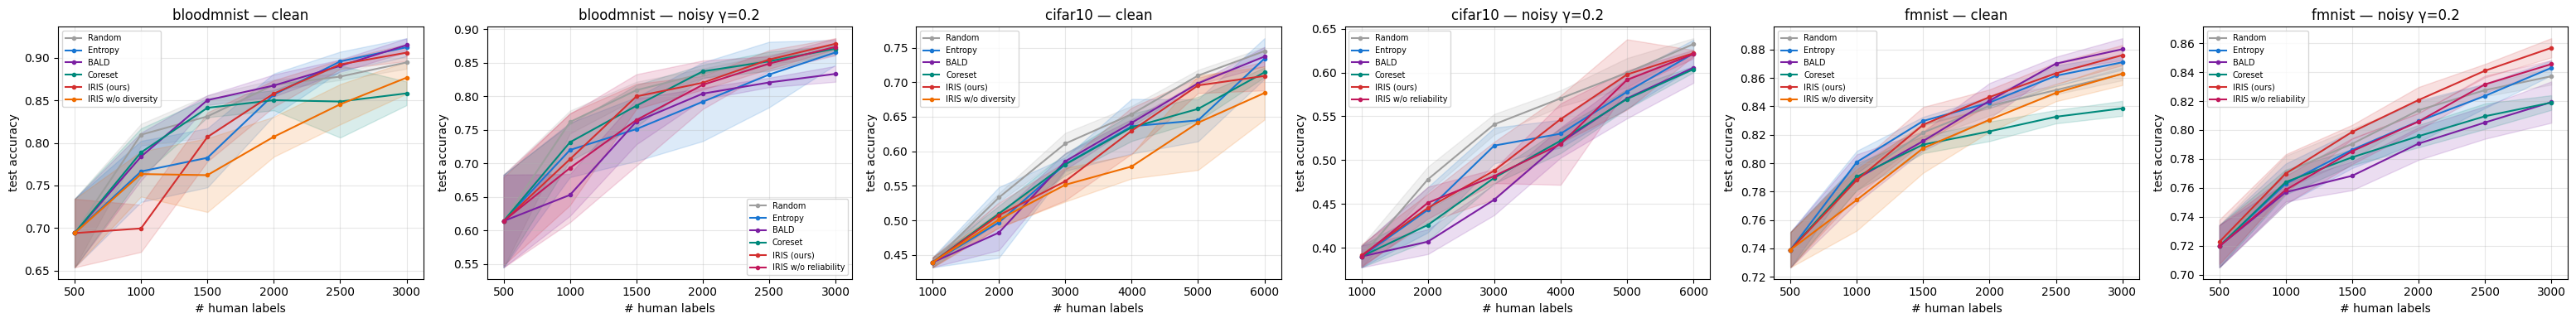

In [5]:
# Learning curves: accuracy vs annotation budget (mean ± std over seeds)
import matplotlib.pyplot as plt

METHOD_ORDER = ["random", "entropy", "bald", "coreset", "iris",
                "iris-nodiv", "iris-norel"]
LAB = {"random": "Random", "entropy": "Entropy", "bald": "BALD",
       "coreset": "Coreset", "learnloss": "Learning-Loss", "badge": "BADGE", "badge-rel": "BADGE + reliability",
       "iris": "IRIS (ours)", "iris-grad": "IRIS-grad (ours)",
       "iris-nodiv": "IRIS w/o diversity", "iris-norel": "IRIS w/o reliability"}
COL = {"random": "#9e9e9e", "entropy": "#1976d2", "bald": "#7b1fa2",
       "coreset": "#00897b", "learnloss": "#5d4037", "badge": "#455a64", "badge-rel": "#0277bd",
       "iris": "#d32f2f", "iris-grad": "#ad1457",
       "iris-nodiv": "#ef6c00", "iris-norel": "#c2185b"}

if df is not None:
    combos = [(ds, nz) for ds in sorted(df.dataset.unique())
              for nz in sorted(df[df.dataset == ds].noise.unique())]
    fig, axes = plt.subplots(1, len(combos), figsize=(5.2 * len(combos), 4),
                             squeeze=False)
    for ax, (ds, nz) in zip(axes[0], combos):
        sub = df[(df.dataset == ds) & (df.noise == nz)]
        for m in METHOD_ORDER:
            g = sub[sub.method == m]
            if g.empty:
                continue
            piv = g.pivot_table(index="n_labeled", columns="seed", values="test_acc")
            mean, std = piv.mean(1), piv.std(1).fillna(0)
            ax.plot(piv.index, mean, "o-", ms=3, color=COL[m], label=LAB[m])
            ax.fill_between(piv.index, mean - std, mean + std, color=COL[m], alpha=0.15)
        ax.set_title(f"{ds} — {'clean' if nz == 0 else f'noisy γ={nz}'}")
        ax.set_xlabel("# human labels"); ax.set_ylabel("test accuracy")
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

In [6]:
# Summary table: final accuracy and AUBC per method/setting
import numpy as np

def aubc(n, a):
    n, a = np.asarray(n, float), np.asarray(a, float)
    o = np.argsort(n)
    return np.trapezoid(a[o], n[o]) / (n[o][-1] - n[o][0])

if df is not None:
    rows = []
    for (ds, nz, m), g in df.groupby(["dataset", "noise", "method"]):
        piv = g.pivot_table(index="n_labeled", columns="seed", values="test_acc")
        aubcs = [aubc(piv.index, piv[c].values) for c in piv.columns]
        finals = piv.loc[piv.index.max()].values
        rows.append(dict(dataset=ds, noise=nz, method=LAB.get(m, m),
                         final_acc=f"{100*np.mean(finals):.2f} ± {100*np.std(finals):.2f}",
                         AUBC=f"{100*np.mean(aubcs):.2f} ± {100*np.std(aubcs):.2f}"))
    display(pd.DataFrame(rows).sort_values(["dataset", "noise"]).reset_index(drop=True))

,dataset,noise,method,final_acc,AUBC
0,bloodmnist,0.0,BADGE,92.20 ± 0.94,85.10 ± 0.43
1,bloodmnist,0.0,BALD,91.50 ± 0.73,83.94 ± 0.84
2,bloodmnist,0.0,Coreset,85.83 ± 1.27,82.10 ± 0.80
3,bloodmnist,0.0,Entropy,91.25 ± 0.97,82.10 ± 1.33
4,bloodmnist,0.0,IRIS (ours),90.62 ± 0.91,81.14 ± 0.53
5,bloodmnist,0.0,IRIS-grad (ours),90.61 ± 0.97,80.28 ± 0.76
6,bloodmnist,0.0,IRIS w/o diversity,87.67 ± 1.73,79.27 ± 0.95
7,bloodmnist,0.0,Learning-Loss,88.15 ± 1.89,75.71 ± 1.56
8,bloodmnist,0.0,Random,89.47 ± 0.68,83.63 ± 0.98
9,bloodmnist,0.2,BADGE,88.42 ± 0.70,80.90 ± 1.20


In [7]:
# Diagnostic: does the introspection head out-rank entropy at error prediction?
diag_path = os.path.join(RESULTS_DIR, "diagnostics.csv")
if os.path.exists(diag_path):
    dg = pd.read_csv(diag_path)
    dg = dg[(dg.method == "iris")]
    piv = dg.groupby(["dataset", "round"])[
        ["auroc_introspection", "auroc_entropy"]].mean().round(4)
    display(piv)
else:
    print("diagnostics.csv not found yet")

auroc_introspection  auroc_entropy
dataset    round                                    
bloodmnist 0                   0.7473         0.7623
           1                   0.7245         0.7652
           2                   0.7759         0.8364
           3                   0.7853         0.8498
           4                   0.8187         0.8851
           5                   0.8299         0.8914
cifar10    0                   0.5989         0.6714
           1                   0.6086         0.6882
           2                   0.6102         0.6996
           3                   0.6473         0.7359
           4                   0.6712         0.7576
           5                   0.6761         0.7666
fmnist     0                   0.7588         0.8199
           1                   0.7476         0.8247
           2                   0.7405         0.8291
           3                   0.7438         0.8355
           4                   0.7516         0.8484
           5                   0.7593         0.8537

## 5. Verifying the saved models
Each run keeps the final trained model that produced its published accuracy, in `checkpoints/`, together with the examples it was trained on and the labels the (possibly lying) oracle returned. The cell below reloads a sample of them and re-measures accuracy on the untouched test set: a clean result is a delta of 0.0000 for every checkpoint.

Training is deterministic (cuDNN autotuning off, DataLoader seeded), so these numbers reproduce exactly rather than approximately.

In [8]:
# Re-measure saved checkpoints.  Needs a GPU; set SAMPLE=None for all 174.
SAMPLE = 6
import glob, torch, random as _rnd
sys.path.insert(0, os.path.join(ROOT, "src"))
paths = sorted(glob.glob(os.path.join(ROOT, "checkpoints", "*.pt")))
if not paths:
    print("no checkpoints — run the grid with --save-checkpoints first")
else:
    import verify_checkpoint as V
    sel = paths if SAMPLE is None else _rnd.Random(0).sample(paths, min(SAMPLE, len(paths)))
    cache, worst = {}, 0.0
    print(f"{'checkpoint':<52}{'recorded':>10}{'reloaded':>10}{'delta':>9}")
    for cp in sel:
        ck, acc, d = V.verify(cp, cache)
        worst = max(worst, abs(d))
        print(f"{os.path.basename(cp):<52}{ck['test_acc']:>10.4f}{acc:>10.4f}{d:>+9.4f}")
    print(f"\nmax |delta| over {len(sel)} checkpoint(s) = {worst:.6f}")

checkpoint                                            recorded  reloaded    delta


fmnist_bald_noise0.2_seed2_round5.pt                    0.8103    0.8103  +0.0000


fmnist_entropy_noise0.0_seed2_round5.pt                 0.8749    0.8749  +0.0000


bloodmnist_bald_noise0.0_seed2_round5.pt                0.9187    0.9187  +0.0000


cifar10_coreset_noise0.2_seed0_round5.pt                0.6012    0.6012  +0.0000


fmnist_learnloss_noise0.0_seed0_round5.pt               0.8709    0.8709  +0.0000


fmnist_iris-norel_noise0.2_seed5_round5.pt              0.8458    0.8458  +0.0000

max |delta| over 6 checkpoint(s) = 0.000000


## 6. Where everything lives
- **Reported figures:** regenerated from `results/` by `src/make_numbers.py`
  and `src/make_plots.py` (rerun together by `src/finalize.sh`).
- **Saved models:** `checkpoints/` — the final model of each of the 174 runs,
  re-checkable with `src/verify_checkpoint.py` (section 5).
- **Previous results:** `results/previous_run/` — the earlier grid, with
  `src/compare_runs.py` to diff old against new.
- **Reproduce from scratch:** `tmux new-session -d -s iris 'bash src/rerun_all.sh
  > logs/rerun.log 2>&1'`, wait for `RERUN COMPLETE`, then re-run section 4 here.
